# Imports

In [1]:
import math
import numpy as np
import pandas as pd
import plotly.express as px
import pickle

# Data Loading

In [2]:
import os
os.listdir('/kaggle/input')
os.listdir('/kaggle/input/datasets/aaditmunje/trainx-csv')

['train.csv']

In [3]:
df = pd.read_csv('/kaggle/input/datasets/aaditmunje/trainx-csv/train.csv')
df.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


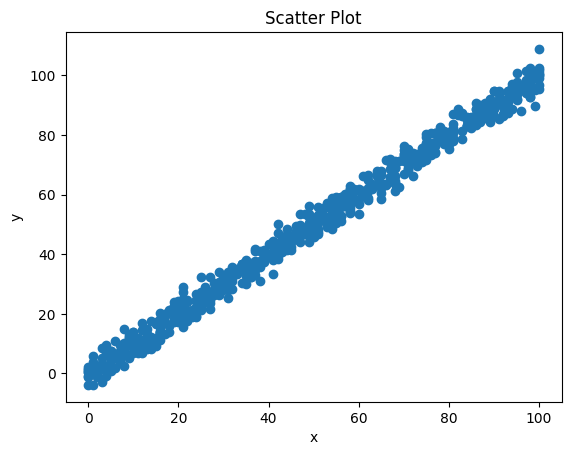

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title("Scatter Plot")
plt.show()



# Data Preprocessing

## Standardize the data
Standardization, also known as Z-score normalization, helps in rescaling the data. What this means in simple words is: Mean = 0 Standard Deviation = 1
### Why Use Standardization in Machine Learning?
Standardization helps bring all the features to one common scale/ similar scale so that it gets easier to compare. This helps in improving the efficiency of the data
Example - If we compare the height and age of a person, the data 12 could mean both 12 years old and 12 inches. In such cases, standardization avoids the dominance of a  single feature by bringing everything to the same scale

### How to Standardize Data

x = original value
μ = mean of the data
σ = standard deviation
z = standardized value

z = (x - μ)/ σ

## Reshaping data for the correct shape for the model

why cant we make the model without reshaping?

ML libraries (like sklearn and numpy) require data in a specific format. They expect X to be a 2D array of shape (sample, feature), and if we write it only as 1D, it will give an error. Eg- If we just write (50), the model does not understand whether it is 50 sample or feature and creates ambiguity.

# Model Implementation

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standardize both columns
df[['x', 'y']] = scaler.fit_transform(df[['x', 'y']])

df.head()

,x,y
0,-0.230232,-0.976005
1,-0.037047,-0.085099
2,-0.297104,-1.124889
3,-0.126209,-0.459065
4,0.237872,1.283987


Basically, the mean is now zero, and the data are more spread out (σ=1). Here, 87 becomes a large positive value

15 becomes a large negative value

# Linear Regression Model

Linear regression is a fundamental model in machine learning used for predicting a continuous output variable based on input features. The model function for linear regression is represented as:

$$f_{w,b}(x) = wx + b$$

In this equation, $f_{w,b}(x)$ represents the predicted output, $w$ is the weight parameter, $b$ is the bias parameter, and $x$ is the input feature.

## Model Training

To train a linear regression model, we aim to find the best values for the parameters $(w, b)$ that best fit our dataset.

### Forward Pass

The forward pass is a step where we compute the linear regression output for the input data $X$ using the current weights and biases. It's essentially applying our model to the input data.

### Cost Function

The cost function is used to measure how well our model is performing. It quantifies the difference between the predicted values and the actual values in our dataset. The cost function is defined as:

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Here, $J(w, b)$ is the cost, $m$ is the number of training examples, $x^{(i)}$ is the input data for the $i$-th example, $y^{(i)}$ is the actual output for the $i$-th example, and $w$ and $b$ are the weight and bias parameters, respectively.

### Backward Pass (Gradient Computation)

The backward pass computes the gradients of the cost function with respect to the weights and biases. These gradients are crucial for updating the model parameters during training. The gradient formulas are as follows:

$$
\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})
$$

$$
\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})X^{(i)}
$$

## Training Process

The training process involves iteratively updating the weights and biases to minimize the cost function. This is typically done through an optimization algorithm like gradient descent. The update equations for parameters are:

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}$$

$$b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

Here, $\alpha$ represents the learning rate, which controls the step size during parameter updates.

By iteratively performing the forward pass, computing the cost, performing the backward pass, and updating the parameters, the model learns to make better predictions and fit the data.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

class LinearRegression:

    def __init__(self, lr=0.0001):
        self.lr = lr

    def initialize_parameters(self):
        self.m = 0  # slope
        self.b = 0  # intercept

    def forward(self, X):
        return self.m * X + self.b

    def compute_cost(self, y, y_pred):
        n = len(y)
        cost = (1/n) * np.sum((y - y_pred) ** 2)
        return cost

    def backward(self, X, y, y_pred):
        n = len(y)
        dm = (-2/n) * np.sum(X * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)

        self.m = self.m - self.lr * dm
        self.b = self.b - self.lr * db

    def fit(self, X, y, iterations, plot_cost=True):
        self.initialize_parameters()
        costs = []

        for i in range(iterations):
            y_pred = self.forward(X)
            cost = self.compute_cost(y, y_pred)
            self.backward(X, y, y_pred)

            costs.append(cost)

            if i % 100 == 0:
                print(f"Iteration {i}, Cost: {cost}")

        if plot_cost:
            plt.plot(costs)
            plt.title("Cost vs Iterations")
            plt.xlabel("Iterations")
            plt.ylabel("Cost")
            plt.show()

    def predict(self, X):
        return self.forward(X)

    def save_model(self, filename="model.pkl"):
        with open(filename, "wb") as f:
            pickle.dump((self.m, self.b), f)

    @classmethod
    def load_model(cls, filename):
        with open(filename, "rb") as f:
            m, b = pickle.load(f)

        model = cls()
        model.m = m
        model.b = b
        return model

In [18]:
# Clean data
df['x'] = pd.to_numeric(df['x'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df.dropna()

# Standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df[['x']]).flatten()
y = scaler.fit_transform(df[['y']]).flatten()


Iteration 0, Cost: 1.0
Iteration 100, Cost: 0.6731196282812861
Iteration 200, Cost: 0.45409290771194244
Iteration 300, Cost: 0.30733370014275085
Iteration 400, Cost: 0.20899745628012956
Iteration 500, Cost: 0.14310709739106456
Iteration 600, Cost: 0.09895715608768198
Iteration 700, Cost: 0.06937441667092034
Iteration 800, Cost: 0.04955245438593351
Iteration 900, Cost: 0.036270716569427874


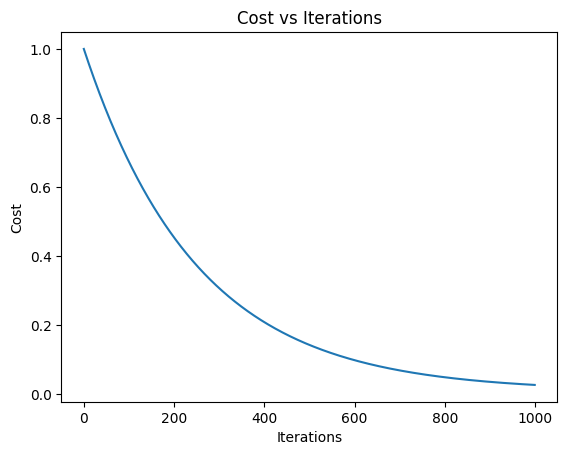

In [19]:
lr = LinearRegression(lr=0.001)
lr.fit(X, y, iterations=1000)

In [21]:
lr.save_model('model.pkl')

# Evaluation



### 1. Mean Squared Error (MSE)

**Formula:**
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_{\text{true}_i} - y_{\text{pred}_i})^2
$$

**Description:**
 - It is an evaluation metric that calculates the average of the squared differences between the actual and predicted values for all the data points. Here, the squaring is done so that the negative and positive values don't cancel each other.

**Interpretation:**
-  MSE basically measures how far your predictions are from the actual values.
-  MSE = 0 : perfect predictions
-  Higher MSE : bad/worse predictions
-  Also the MSE is squared for 2 reasons. First, as mentioned above is so that there aren't any -ve errors, and secondly, it is so that the larger errors get amplified and identified by the model.

### 2. Root Mean Squared Error (RMSE)

**Formula:**
$$
\text{RMSE} = \sqrt{\text{MSE}}
$$

**Description:**
- RMSE is nothing but the square root of MSE. We take the square root to bring the error back to the same unit as our original data, making it much easier to understand

**Interpretation:**
- RMSE is easier to understand than MSE. So it tells me on average, how far (in actual units) my predictions are from real values.
- A lower RMSE = better. Eg. if RMSE is 4.45 dollars means on average we are down by $4.


### 3. R-squared ($R^2$)

**Formula:**
$$
R^2 = 1 - \frac{\text{SSR}}{\text{SST}}
$$

**Description:**
R² tells us how well our model fits the data overall. It compares our model's predictions against a very simple baseline — what if we just predicted the average value every single time? R² measures how much better our model is compared to the baseline.

**Interpretation:**
R² always lies between 0 and 1.
Values:
- R²=1 : Model prediction is perfect
- R²=0 : Poor model prediction (as good as a guess
- R² = 0.9876 :  model explains 98.76% of the variation in the data
- So R² closer to 1, the better.



In [22]:
class RegressionMetrics:

    @staticmethod
    def mean_squared_error(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    @staticmethod
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(RegressionMetrics.mean_squared_error(y_true, y_pred))

    @staticmethod
    def r_squared(y_true, y_pred):
        # SSR = sum of squared residuals
        # SST = total sum of squares
        ssr = np.sum((y_true - y_pred) ** 2)
        sst = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - (ssr / sst)

In [26]:
y_pred = lr.predict(X)

mse_value = RegressionMetrics.mean_squared_error(y, y_pred)
rmse_value = RegressionMetrics.root_mean_squared_error(y, y_pred)
r_squared_value = RegressionMetrics.r_squared(y, y_pred)

print(f"Mean Squared Error (MSE): {mse_value:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_value:.4f}")
print(f"R-squared: {r_squared_value:.4f}")

Mean Squared Error (MSE): 0.0274
Root Mean Squared Error (RMSE): 0.1654
R-squared: 0.9726


Here we are standardizing x to predict the final data

Iteration 0, Cost: 1.0
Iteration 100, Cost: 0.6731953967576682
Iteration 200, Cost: 0.45421944497819466
Iteration 300, Cost: 0.3074942551185828
Iteration 400, Cost: 0.20918080487716137
Iteration 500, Cost: 0.14330571889076388
Iteration 600, Cost: 0.09916601122046033
Iteration 700, Cost: 0.06959012886605777
Iteration 800, Cost: 0.04977276116677049
Iteration 900, Cost: 0.036494101959826955
MSE: 24.0115469839742
RMSE: 4.900157852964964


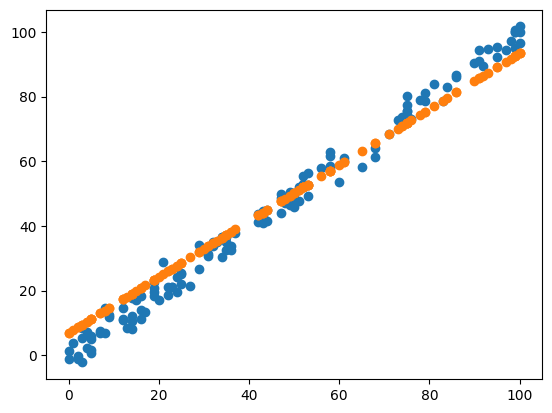

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv('/kaggle/input/datasets/aaditmunje/trainx-csv/train.csv')

df['x'] = pd.to_numeric(df['x'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')

df = df.dropna()

X = df['x'].values
y = df['y'].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

mean_x, std_x = X_tr.mean(), X_tr.std()
mean_y, std_y = y_tr.mean(), y_tr.std()

if std_x == 0:
    std_x = 1
if std_y == 0:
    std_y = 1

X_train2 = (X_tr - mean_x) / std_x
X_test2  = (X_te - mean_x) / std_x
y_train2 = (y_tr - mean_y) / std_y

class LinearRegression:
    def __init__(self, lr=0.001):
        self.lr = lr

    def initialize_parameters(self):
        self.m = 0
        self.b = 0

    def forward(self, X):
        return self.m * X + self.b

    def compute_cost(self, y, y_pred):
        return np.mean((y - y_pred) ** 2)

    def backward(self, X, y, y_pred):
        n = len(y)
        dm = (-2/n) * np.sum(X * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)

        self.m -= self.lr * dm
        self.b -= self.lr * db

    def fit(self, X, y, iterations=1000, plot_cost=True):
        self.initialize_parameters()
        costs = []

        for i in range(iterations):
            y_pred = self.forward(X)
            cost = self.compute_cost(y, y_pred)
            self.backward(X, y, y_pred)

            costs.append(cost)

            if i % 100 == 0:
                print(f"Iteration {i}, Cost: {cost}")

        if plot_cost:
            plt.plot(costs)
            plt.title("Cost vs Iterations")
            plt.show()

    def predict(self, X):
        return self.forward(X)

model = LinearRegression(lr=0.001)
model.fit(X_train2, y_train2, iterations=1000, plot_cost=False)

y_pred2 = model.predict(X_test2) * std_y + mean_y

mse = np.mean((y_te - y_pred2) ** 2)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

plt.scatter(X_te, y_te)
plt.scatter(X_te, y_pred2)
plt.show()